In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap

## Augmentations

In [3]:
augmentations = ["rotation", "blur", "brightness", "crop"]
cmap_blue = LinearSegmentedColormap.from_list(
    "blues", ["#7db9cd", "#2663be", "#252587"]
)

In [4]:
augmentation_matrix = [[None] * 4 for _ in range(4)]
order = [(0,0), (1,1), (2,2), (3,3), (0,1), (1,2), (2,3), (0,2), (1,3), (0,3)]

for i in range(10):
    df = pd.read_csv(f"ssl_history_ssl_augmentations_1.{i+1}.csv", sep=";")
    max_acc = float(df["val_accuracy"].max())
    time = float(df["time"].sum())

    augmentation_matrix[(order[i][0])][(order[i][1])] = max_acc

for i in range(4):
    for j in range(4):
        augmentation_matrix[j][i] = augmentation_matrix[i][j]

for row in augmentation_matrix:
    print(row)

# Additional augmentations from v1.6.11 to v1.6.14
additional_augmentations = []
for i in range(11, 15):
    df = pd.read_csv(f"ssl_history_ssl_augmentations_1.{i}.csv", sep=";")
    max_acc = float(df["val_accuracy"].max())
    additional_augmentations.append(max_acc)

print("\nAdditional augmentations (v1.6.11 to v1.6.14):")
print(additional_augmentations)

# All augmentations combinations (v1.6.15 and v1.6.16)
all_augmentations = []
for i in range(15, 16):
    df = pd.read_csv(f"ssl_history_ssl_augmentations_1.{i}.csv", sep=";")
    max_acc = float(df["val_accuracy"].max())
    all_augmentations.append(max_acc)

print("\nAll augmentations (v1.6.15 and v1.6.16):")
print(all_augmentations)

[0.8748549323017408, 0.8874274661508704, 0.9195357833655706, 0.9102514506769824]
[0.8874274661508704, 0.854835589941973, 0.8842359767891683, 0.9207930367504836]
[0.9195357833655706, 0.8842359767891683, 0.8841392649903288, 0.9376208897485492]
[0.9102514506769824, 0.9207930367504836, 0.9376208897485492, 0.9254352030947776]

Additional augmentations (v1.6.11 to v1.6.14):
[0.9205029013539652, 0.9138297872340424, 0.9311411992263056, 0.9381044487427466]

All augmentations (v1.6.15 and v1.6.16):
[0.935009671179884]


Text(108.22222222222221, 0.5, '')

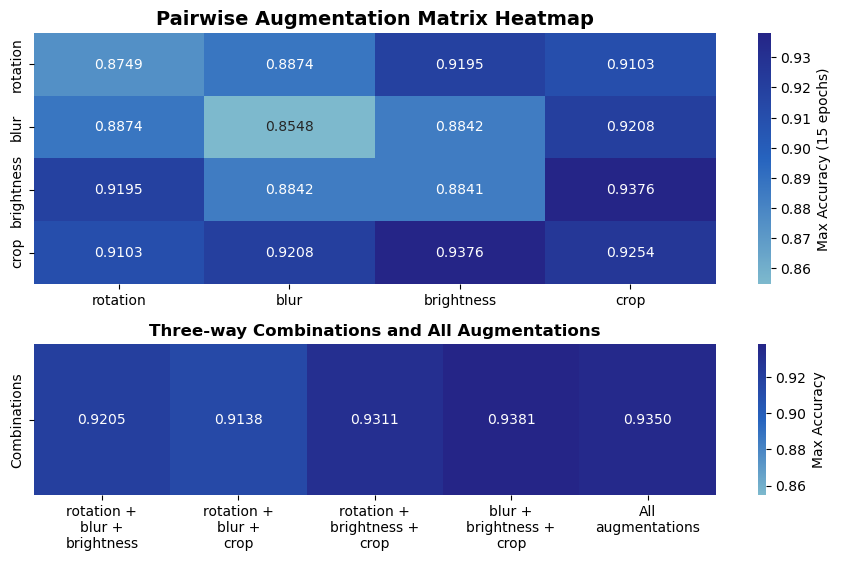

In [5]:
# Calculate global min and max for consistent color scaling
all_values = []
for row in augmentation_matrix:
    all_values.extend([val for val in row if val is not None])
all_values.extend(additional_augmentations)
all_values.extend(all_augmentations)
vmin = min(all_values)
vmax = max(all_values)

# Create figure with custom grid layout
fig = plt.figure(figsize=(11, 6))
gs = GridSpec(2, 2, figure=fig, height_ratios=[1, 0.6], width_ratios=[0.8, 0.4], hspace=0.3, wspace=0.05)

# First heatmap: 4x4 augmentation matrix (spans full width on top)
ax1 = fig.add_subplot(gs[0, :])
sns.heatmap(augmentation_matrix, 
            annot=True, 
            fmt='.4f', 
            cmap=cmap_blue,#'YlOrRd',
            xticklabels=augmentations,
            yticklabels=augmentations,
            cbar_kws={'label': 'Max Accuracy (15 epochs)'},
            vmin=vmin,
            vmax=vmax,
            ax=ax1)
ax1.set_title('Pairwise Augmentation Matrix Heatmap', fontsize=14, fontweight='bold')

# Second heatmap: 1x5 for additional augmentations (v1.6.11 to v1.6.15)
ax2 = fig.add_subplot(gs[1, :])   # bottom row spans full width

# Build a single row with 5 cells:
# 4 three-way combinations + 1 all-augmentations value
combined_matrix = [additional_augmentations + [all_augmentations[0]]]

xticklabels = [
    'rotation +\nblur +\nbrightness',
    'rotation +\nblur +\ncrop',
    'rotation +\nbrightness +\ncrop',
    'blur +\nbrightness +\ncrop',
    'All\naugmentations'
]

sns.heatmap(
    combined_matrix,
    annot=True,
    fmt='.4f',
    cmap=cmap_blue,#'YlOrRd',
    xticklabels=xticklabels,
    yticklabels=['Combinations'],
    cbar_kws={'label': 'Max Accuracy'},
    vmin=vmin,
    vmax=vmax,
    ax=ax2
)

ax2.set_title('Three-way Combinations and All Augmentations', fontsize=12, fontweight='bold')
ax2.set_ylabel('')

## Enhancements for brightness and contrast transformations

In [6]:
enhancements = ["min_max_stretch", "global_threshold", "percentile_stretch", "meteors_stretch"]

cmap_green = LinearSegmentedColormap.from_list(
    "yellow_green_darkgreen",
    ["#e3e383",  # yellow
     "#457e45",  # green
     "#005500"]  # dark green
)

In [7]:
enhancements_matrix = [[None] * 4 for _ in range(4)]
order = [(0,0), (1,1), (2,2), (3,3), (0,1), (1,2), (2,3), (0,2), (1,3), (0,3)]

for i in range(10):
    df = pd.read_csv(f"ssl_history_ssl_augmentations_2.{i+1}.csv", sep=";")
    max_acc = float(df["val_accuracy"].max())
    time = float(df["time"].sum())

    enhancements_matrix[(order[i][0])][(order[i][1])] = max_acc

for i in range(4):
    for j in range(4):
        enhancements_matrix[j][i] = enhancements_matrix[i][j]

for row in enhancements_matrix:
    print(row)

# Additional augmentations from v1.6.11 to v1.6.14
additional_enhancements = []
for i in range(11, 15):
    df = pd.read_csv(f"ssl_history_ssl_augmentations_2.{i}.csv", sep=";")
    max_acc = float(df["val_accuracy"].max())
    additional_enhancements.append(max_acc)

print("\nAdditional augmentations (v1.6.11 to v1.6.14):")
print(additional_enhancements)

# All augmentations combinations (v1.6.15 and v1.6.16)
all_enhancements = []
for i in range(15, 16):
    df = pd.read_csv(f"ssl_history_ssl_augmentations_2.{i}.csv", sep=";")
    max_acc = float(df["val_accuracy"].max())
    all_enhancements.append(max_acc)

print("\nAll augmentations (v1.6.15 and v1.6.16):")
print(all_enhancements)

[0.9358800773694392, 0.9380077369439072, 0.9352030947775628, 0.9380077369439072]
[0.9380077369439072, 0.9358800773694392, 0.9367504835589942, 0.9359767891682784]
[0.9352030947775628, 0.9367504835589942, 0.9330754352030948, 0.9376208897485492]
[0.9380077369439072, 0.9359767891682784, 0.9376208897485492, 0.9356866537717602]

Additional augmentations (v1.6.11 to v1.6.14):
[0.940328820116054, 0.9401353965183752, 0.9386847195357834, 0.93752417794971]

All augmentations (v1.6.15 and v1.6.16):
[0.939458413926499]


[Text(0.5, 0, 'min_max_stretch +\nglobal_threshold +\npercentile_stretch'),
 Text(1.5, 0, 'min_max_stretch +\nglobal_threshold +\nmeteors_stretch'),
 Text(2.5, 0, 'min_max_stretch +\npercentile_stretch +\nmeteors_stretch'),
 Text(3.5, 0, 'global_threshold +\npercentile_stretch +\nmeteors_stretch'),
 Text(4.5, 0, 'All\ntogether')]

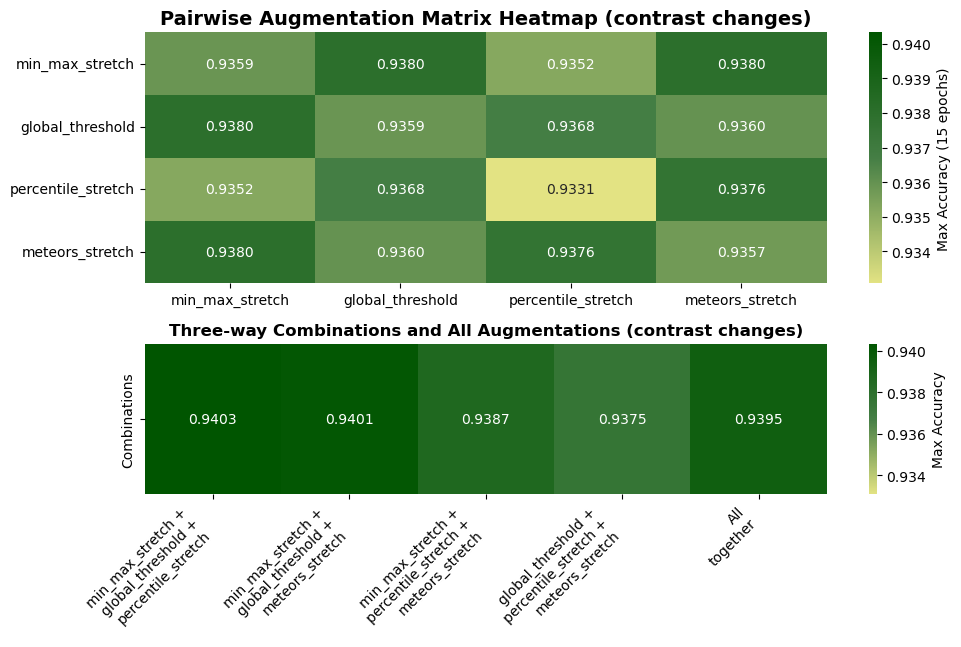

In [8]:
# Calculate global min and max for consistent color scaling
all_values = []
for row in enhancements_matrix:
    all_values.extend([val for val in row if val is not None])
all_values.extend(additional_enhancements)
all_values.extend(all_enhancements)
vmin = min(all_values)
vmax = max(all_values)

# Create figure with custom grid layout
fig = plt.figure(figsize=(11, 6))
gs = GridSpec(2, 2, figure=fig, height_ratios=[1, 0.6], width_ratios=[0.8, 0.4], hspace=0.3, wspace=0.05)

# First heatmap: 4x4 augmentation matrix (spans full width on top)
ax1 = fig.add_subplot(gs[0, :])
sns.heatmap(enhancements_matrix, 
            annot=True, 
            fmt='.4f', 
            cmap=cmap_green,#'YlOrRd',
            xticklabels=enhancements,
            yticklabels=enhancements,
            cbar_kws={'label': 'Max Accuracy (15 epochs)'},
            vmin=vmin,
            vmax=vmax,
            ax=ax1)
ax1.set_title('Pairwise Augmentation Matrix Heatmap (contrast changes)', fontsize=14, fontweight='bold')

# Second heatmap: 1x5 for additional augmentations (v1.6.11 to v1.6.15)
ax2 = fig.add_subplot(gs[1, :])   # bottom row spans full width

# Build a single row with 5 cells:
# 4 three-way combinations + 1 all-augmentations value
combined_matrix = [additional_enhancements + [all_enhancements[0]]]

enhancements = ["min_max_stretch", "global_threshold", "percentile_stretch", "meteors_stretch"]

xticklabels = [
    'min_max_stretch +\nglobal_threshold +\npercentile_stretch',
    'min_max_stretch +\nglobal_threshold +\nmeteors_stretch',
    'min_max_stretch +\npercentile_stretch +\nmeteors_stretch',
    'global_threshold +\npercentile_stretch +\nmeteors_stretch',
    'All\ntogether'
]

sns.heatmap(
    combined_matrix,
    annot=True,
    fmt='.4f',
    cmap=cmap_green,#'YlOrRd',
    xticklabels=xticklabels,
    yticklabels=['Combinations'],
    cbar_kws={'label': 'Max Accuracy'},
    vmin=vmin,
    vmax=vmax,
    ax=ax2
)

ax2.set_title('Three-way Combinations and All Augmentations (contrast changes)', fontsize=12, fontweight='bold')
ax2.set_ylabel('')
ax2.set_xticklabels(xticklabels, rotation=45, ha='right')

In [9]:
def df_to_latex_table(df):
    # Format floats to 4 decimals
    df = df.copy()
    df = df.applymap(lambda x: f"{x:.4f}" if isinstance(x, float) else x)

    # Build header row (index header is empty)
    headers = [""] + [f"\\textbf{{{col}}}" for col in df.columns]
    header_row = " & ".join(headers) + " \\\\"

    # Build data rows
    rows = []
    for idx, row in df.iterrows():
        row_values = [str(idx)] + [str(v) for v in row.values]
        rows.append(" & ".join(row_values) + " \\\\")

    # Build LaTeX table
    ncols = len(df.columns) + 1
    latex = "\\begin{table}[h!]\n\\centering\n\n"
    latex += f"\\begin{{tabular}}{{|{'c|' * ncols}}}\n"
    latex += "\\hline\n"
    latex += header_row + "\n"
    latex += "\\hline\n"
    latex += "\n".join(rows) + "\n"
    latex += "\\hline\n"
    latex += "\\end{tabular}\n"
    latex += "\\caption{Your caption here}\n"
    latex += "\\label{{tab:your_label}}\n"
    latex += "\\end{table}"

    return latex


In [10]:
index = ["R", "BL", "B\\&C", "C", "R + BL", "R + B\\&C", "R + C", "BL + B\\&C", "BL + C", "B\\&C + C", "R + BL + B\\&C", "R + BL + C", "R + B\\&C + C", "BL + B\\&C + C", "All augmentations"]

In [11]:
summary_rows = []
vars = ['contrastive_loss', 'val_accuracy', 'train_accuracy',
        'uniformity', 'alignment', 'std', 'time']

for i in range(15):
    df = pd.read_csv(f"ssl_history_ssl_augmentations_1.{i+1}.csv", sep=";")
    
    last_row = df.iloc[-1].copy()
    
    # Convert dtype so pandas accepts a string
    last_row = last_row.astype("object")
    
    # Compute total time in minutes
    total_seconds = df["time"].sum()
    total_minutes = total_seconds / 60
    last_row["time"] = f"{total_minutes:.2f} min"
    
    summary_rows.append(last_row)

summary = pd.DataFrame(index=index, data=summary_rows)[vars]
summary = summary.map(
    lambda x: f"{x:.4f}" if isinstance(x, float) else x
)
summary = summary.rename(columns={"contrastive_loss": "contrastive loss", "val_accuracy": "test accuracy", "train_accuracy": "train accuracy", "uniformity": "uniformity", "alignment": "alignment", "std": "std", "time": "training time"})
print(df_to_latex_table(summary))

\begin{table}[h!]
\centering

\begin{tabular}{|c|c|c|c|c|c|c|c|}
\hline
 & \textbf{contrastive loss} & \textbf{test accuracy} & \textbf{train accuracy} & \textbf{uniformity} & \textbf{alignment} & \textbf{std} & \textbf{training time} \\
\hline
R & 3.0139 & 0.8684 & 0.8780 & -3.7512 & 0.0117 & 0.7198 & 17.18 min \\
BL & 2.9488 & 0.8271 & 0.8365 & -3.7976 & 0.0003 & 0.6970 & 19.07 min \\
B\&C & 3.0520 & 0.8825 & 0.8919 & -3.6855 & 0.0927 & 0.3055 & 15.80 min \\
C & 3.0149 & 0.9254 & 0.9316 & -3.6609 & 0.0547 & 0.8369 & 14.95 min \\
R + BL & 2.9603 & 0.8776 & 0.8858 & -3.7128 & 0.0164 & 0.6946 & 16.89 min \\
R + B\&C & 3.0279 & 0.8824 & 0.8907 & -3.7309 & 0.0746 & 0.2969 & 17.09 min \\
R + C & 3.1804 & 0.9376 & 0.9405 & -3.3192 & 0.1735 & 0.6257 & 14.40 min \\
BL + B\&C & 3.1445 & 0.9181 & 0.9207 & -3.4068 & 0.1440 & 0.3767 & 14.71 min \\
BL + C & 3.0455 & 0.9208 & 0.9240 & -3.6381 & 0.0608 & 0.8605 & 16.36 min \\
B\&C + C & 3.0524 & 0.9103 & 0.9154 & -3.6128 & 0.0666 & 0.8537 & 14.55 mi

C:\Users\auror\AppData\Local\Temp\ipykernel_23544\2759215063.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: f"{x:.4f}" if isinstance(x, float) else x)


In [12]:
index = ["MMS", "GT", "PS", "MS", "MMS + GT", "MMS + PS", "MMS + MS", "GT + PS", "GT + MS", "PS + MS", "MMS + GT + PS", "MMS + GT + MS", "MMS + PS + MS", "GT + PS + MS", "All enhancements"]

In [13]:
summary_rows = []
vars = ['contrastive_loss', 'val_accuracy', 'train_accuracy',
        'uniformity', 'alignment', 'std', 'time']

for i in range(15):
    df = pd.read_csv(f"ssl_history_ssl_augmentations_2.{i+1}.csv", sep=";")
    
    last_row = df.iloc[-1].copy()
    
    # Convert dtype so pandas accepts a string
    last_row = last_row.astype("object")
    
    # Compute total time in minutes
    total_seconds = df["time"].sum()
    total_minutes = total_seconds / 60
    last_row["time"] = f"{total_minutes:.2f} min"
    
    summary_rows.append(last_row)

summary = pd.DataFrame(index=index, data=summary_rows)[vars]
summary = summary.rename(columns={"val_accuracy": "test_accuracy"})
print(df_to_latex_table(summary))

\begin{table}[h!]
\centering

\begin{tabular}{|c|c|c|c|c|c|c|c|}
\hline
 & \textbf{contrastive_loss} & \textbf{test_accuracy} & \textbf{train_accuracy} & \textbf{uniformity} & \textbf{alignment} & \textbf{std} & \textbf{time} \\
\hline
MMS & 3.1283 & 0.9337 & 0.9389 & -3.3760 & 0.1325 & 0.5740 & 16.80 min \\
GT & 3.4223 & 0.9359 & 0.9370 & -2.9996 & 0.2873 & 0.5193 & 16.72 min \\
PS & 3.1818 & 0.9331 & 0.9374 & -3.2760 & 0.1647 & 0.5397 & 19.06 min \\
MS & 3.3985 & 0.9357 & 0.9392 & -2.9595 & 0.3085 & 0.5113 & 16.64 min \\
MMS + GT & 3.3014 & 0.9363 & 0.9384 & -3.1270 & 0.2508 & 0.4915 & 16.63 min \\
MMS + PS & 3.3224 & 0.9368 & 0.9399 & -3.0824 & 0.2655 & 0.4436 & 17.86 min \\
MMS + MS & 3.3421 & 0.9376 & 0.9397 & -3.0582 & 0.2770 & 0.5291 & 17.93 min \\
GT + PS & 3.1873 & 0.9352 & 0.9383 & -3.3019 & 0.1616 & 0.4920 & 17.93 min \\
GT + MS & 3.3910 & 0.9357 & 0.9386 & -2.9683 & 0.3019 & 0.5296 & 16.56 min \\
PS + MS & 3.3418 & 0.9363 & 0.9403 & -3.1028 & 0.2663 & 0.4899 & 16.74 min \\


C:\Users\auror\AppData\Local\Temp\ipykernel_23544\2759215063.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: f"{x:.4f}" if isinstance(x, float) else x)


In [14]:
complete_df = pd.concat([
    pd.read_csv(f"ssl_history_ssl_augmentations_1.15.csv", sep=";"), 
    pd.read_csv(f"ssl_history_ssl_augmentations_2.11.csv", sep=";")
    ], ignore_index=True)

def scatterplot_alignment_uniformity(df):
    fig, ax = plt.subplots(figsize=(8, 6))

    scatter = ax.scatter(
        x=complete_df["alignment"],
        y=complete_df["uniformity"],
        c=complete_df["val_accuracy"],
        cmap="viridis",   # or any colormap you prefer
        s=60,             # point size
        alpha=0.8,        # transparency for readability
        edgecolor="black",
        linewidth=0.5
    )

    # Labels and title
    ax.set_xlabel("Alignment", fontsize=12)
    ax.set_ylabel("Uniformity", fontsize=12)
    ax.set_title("Alignment vs Uniformity Colored by Validation Accuracy", fontsize=14, fontweight="bold")

    # Colorbar
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("Validation Accuracy")

    plt.tight_layout()
    plt.show()

## Overfitting checks

In [15]:
df1 = pd.read_csv(f"ssl_history_ssl_architecture_3.1.csv", sep=";")
df2 = pd.read_csv(f"ssl_history_ssl_architecture_3.2.csv", sep=";")
df3 = pd.read_csv(f"ssl_history_ssl_architecture_3.3.csv", sep=";")
df4 = pd.read_csv(f"ssl_history_ssl_architecture_3.4.csv", sep=";")

dfs = [df1, df2, df3, df4]
labels=[
    "ResNet-18 + 128-dim Projection Head", 
    "ResNet-18 + 256-dim Projection Head",
    "ResNet-50 + 128-dim Projection Head",
    "ResNet-50 + 256-dim Projection Head"]

In [16]:
def plot_contrastive_loss_evolution(df):
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.lineplot(data=df, x=range(1, len(df)+1), y="contrastive_loss", label="Loss evolution")
    ax.set_title('Contrastive Loss Evolution During Training', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch')

def plot_multiple_losses(dfs, labels=None):
    fig, ax = plt.subplots(figsize=(10, 6))

    if labels is None:
        labels = [f"Run {i+1}" for i in range(len(dfs))]

    for df, label in zip(dfs, labels):
        sns.lineplot(
            data=df,
            x=range(1, len(df)+1),
            y="contrastive_loss",
            ax=ax,
            label=label
        )

    ax.set_title('Contrastive Loss Evolution During Training', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [17]:
def plot_accuracy_evolution(df):
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot train accuracy
    sns.lineplot(
        data=df,
        x=range(1, len(df) + 1),
        y="train_accuracy",
        label="Train Accuracy",
        ax=ax
    )

    # Plot test accuracy
    sns.lineplot(
        data=df,
        x=range(1, len(df) + 1),
        y="val_accuracy",
        label="Test Accuracy",
        ax=ax
    )

    ax.set_title('Accuracy Evolution During Training', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()

def plot_accuracy_evolution_multi(dfs, labels=None):
    fig, ax = plt.subplots(figsize=(10, 6))

    if labels is None:
        labels = [f"Run {i+1}" for i in range(len(dfs))]

    palette = sns.color_palette("tab10", n_colors=len(dfs))

    for df, label, color in zip(dfs, labels, palette):
        epochs = range(1, len(df) + 1)

        # Train accuracy
        sns.lineplot(
            x=epochs,
            y=df["train_accuracy"],
            ax=ax,
            color=color,
            linestyle="-",
            label=f"{label} – Train"
        )

        # Test accuracy
        sns.lineplot(
            x=epochs,
            y=df["val_accuracy"],
            ax=ax,
            color=color,
            linestyle="--",
            label=f"{label} – Test"
        )

    ax.set_title("Accuracy Evolution During Training", fontsize=14, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()
    plt.tight_layout()
    plt.show()


In [18]:
def plot_alignment_uniformity_evolution(df):
    fig, ax1 = plt.subplots(figsize=(10, 6))

    epochs = range(1, len(df) + 1)

    # Left axis: Alignment
    sns.lineplot(
        x=epochs,
        y=df["alignment"],
        ax=ax1,
        color="tab:blue"
    )
    ax1.set_ylabel("Alignment", color="tab:blue")
    ax1.tick_params(axis='y', labelcolor="tab:blue")

    # Right axis: Uniformity
    ax2 = ax1.twinx()
    sns.lineplot(
        x=epochs,
        y=df["uniformity"],
        ax=ax2,
        color="tab:red"
    )
    ax2.set_ylabel("Uniformity", color="tab:red")
    ax2.tick_params(axis='y', labelcolor="tab:red")

    ax1.set_title("Alignment and Uniformity Evolution During Training", fontsize=14, fontweight="bold")
    ax1.set_xlabel("Epoch")

    plt.tight_layout()
    plt.show()

def plot_alignment_uniformity_evolution_multi(dfs, labels=None):
    fig, ax1 = plt.subplots(figsize=(10, 6))

    if labels is None:
        labels = [f"Run {i+1}" for i in range(len(dfs))]

    # Up to 4 distinct line styles
    linestyles = ["-", "--", ":", "-."]
    linestyles = linestyles[:len(dfs)]

    # Right axis
    ax2 = ax1.twinx()

    # Store handles for custom legend
    legend_handles = []

    for df, label, ls in zip(dfs, labels, linestyles):
        epochs = range(1, len(df) + 1)

        # Alignment (blue)
        sns.lineplot(
            x=epochs,
            y=df["alignment"],
            ax=ax1,
            color="tab:blue",
            linestyle=ls
        )

        # Uniformity (red)
        sns.lineplot(
            x=epochs,
            y=df["uniformity"],
            ax=ax2,
            color="tab:red",
            linestyle=ls
        )

        # Create a black line with the same linestyle for the legend
        handle = plt.Line2D(
            [0], [0],
            color="black",
            linestyle=ls,
            label=label
        )
        legend_handles.append(handle)

    # Axis labels
    ax1.set_ylabel("Alignment", color="tab:blue")
    ax1.tick_params(axis='y', labelcolor="tab:blue")

    ax2.set_ylabel("Uniformity", color="tab:red")
    ax2.tick_params(axis='y', labelcolor="tab:red")

    ax1.set_title("Alignment and Uniformity Evolution During Training", fontsize=14, fontweight="bold")
    ax1.set_xlabel("Epoch")

    # Single legend with black line styles
    ax1.legend(handles=legend_handles, title="Runs", loc="upper right")

    plt.tight_layout()
    plt.show()


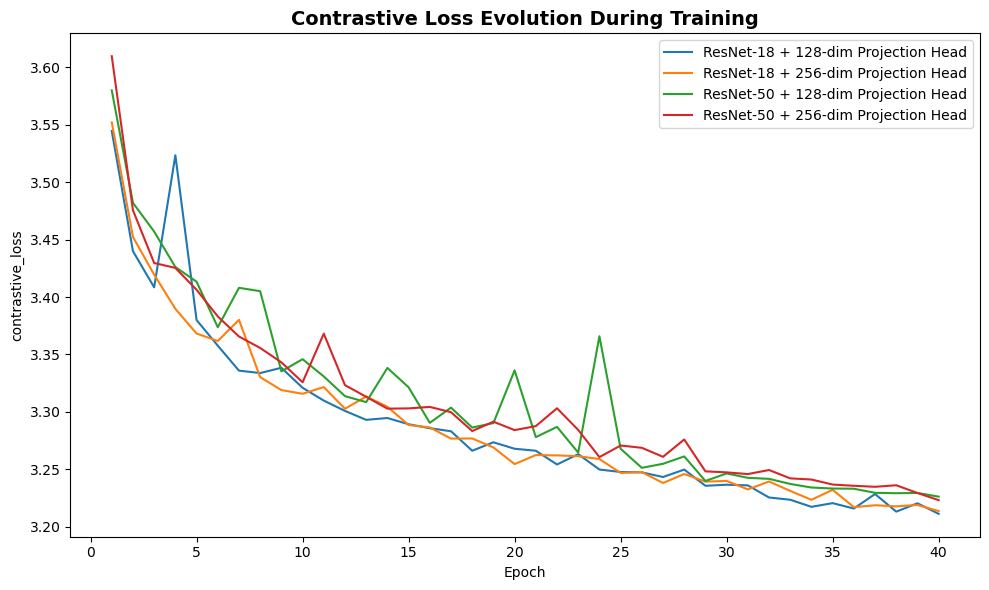

In [19]:
plot_multiple_losses(dfs, labels)

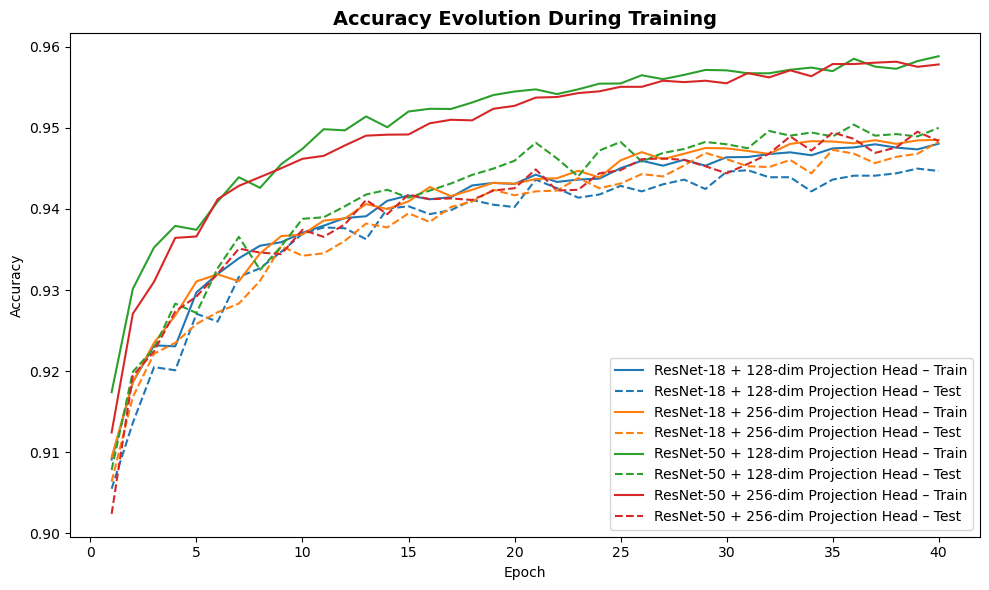

In [20]:
plot_accuracy_evolution_multi(dfs, labels)

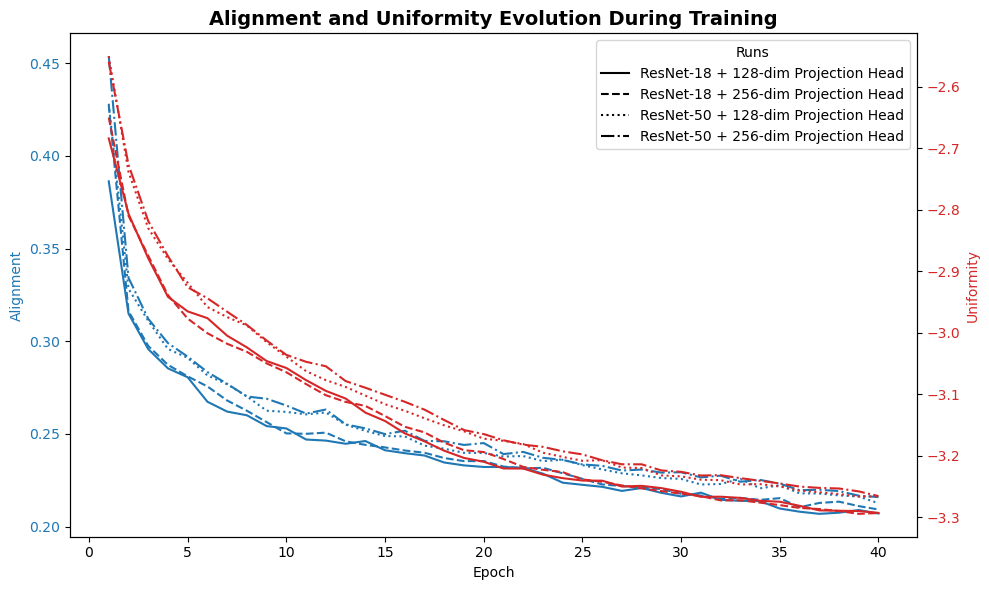

In [21]:
plot_alignment_uniformity_evolution_multi(dfs, labels)